Connected to Python 3.14.2

In [2]:
import numpy as np

def mu(T):
    A = 2.414e-5
    B = 247.8

    C = 140

    mu_ = A * 10 ** (B / (T - C))
    return mu_


def Celsius_to_Kelvin(T_C):
    return T_C + 273.15






In [3]:
def rho(temperature, pressure):
    T = temperature - Celsius_to_Kelvin(20)

    rho_ref = 1000 - 0.07 * T - 0.0002 * T**2
    dp = pressure - 1e5

    # Wrap compressibility from fluid class as matrix (left multiplication with dp).
    c = 4.5e-10
    rho_ = rho_ref * (1 + c * dp)


    return rho_

def rho_old(temperature, pressure):
    pressure_exponential = np.exp(4.5e-10 * (pressure - 1e5))
    thermal_expansion = 2.068e-4
    temperature_exponential = np.exp(-thermal_expansion* (temperature - 293.15))
    rho_ = 1000 * pressure_exponential * temperature_exponential
    return rho_

In [7]:
N = 20
T = np.linspace(310, 560, N)
p = np.ones(20) * 1e7
visc = mu(T)
dens = rho(T,p)
dens_old = rho_old(T,p)



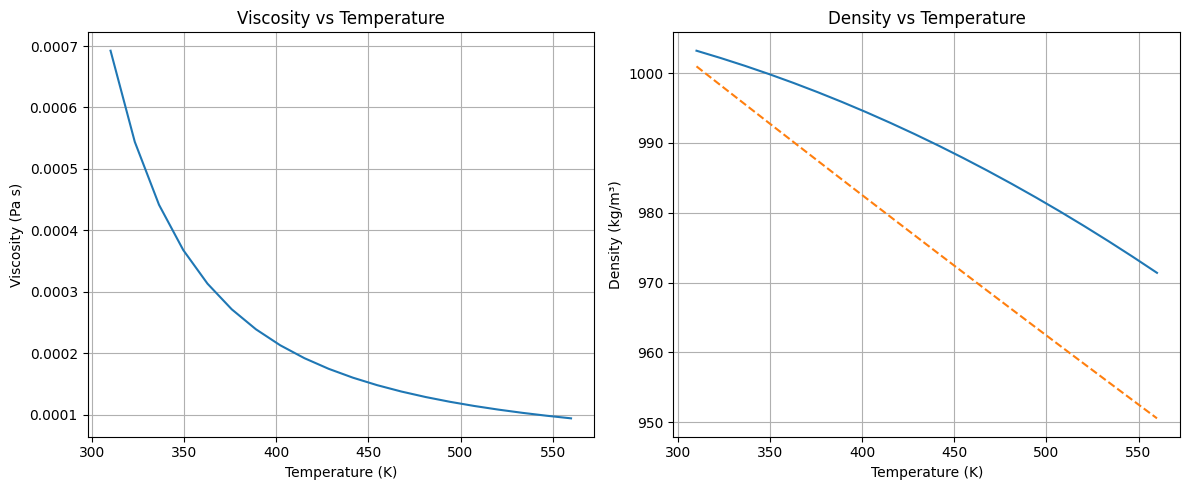

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(T, visc)
plt.xlabel("Temperature (K)")
plt.ylabel("Viscosity (Pa s)")
plt.title("Viscosity vs Temperature")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(T, dens)
plt.plot(T, dens_old, "--")
plt.xlabel("Temperature (K)")
plt.ylabel("Density (kg/m³)")
plt.title("Density vs Temperature")
plt.grid()
plt.tight_layout()
plt.show()

In [6]:
3e-4 ** 3 /12


2.2499999999999995e-12